In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
df=pd.read_csv('my_project1.csv')

In [3]:
df.sample(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
21,"November 19, 2025",7.0,32.0,3.0,"2,340",10.0
274,"November 11, 2024",118.0,139.0,168.0,"5,963",145.0
1130,NaN,NaN,NaN,NaN,NaN,NaN
831,NaN,NaN,NaN,NaN,NaN,NaN
855,NaN,NaN,NaN,NaN,NaN,NaN
751,NaN,NaN,NaN,NaN,NaN,NaN
1156,NaN,NaN,NaN,NaN,NaN,NaN
340,"August 04, 2024",63.0,167.0,143.0,"5,943",170.0
596,"July 23, 2023",108.0,220.0,213.0,"7,052",276.0
77,"August 28, 2025",8.0,33.0,6.0,"1,984",17.0


In [4]:
df.dtypes

Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

In [5]:
df = df.rename(columns={
    'Children apprehended and placed in CBP custody*': 'cbp_intake',
    'Children in CBP custody': 'cbp_custody',
    'Children transferred out of CBP custody': 'transfers',
    'Children in HHS Care': 'hhs_care',
    'Children discharged from HHS Care': 'discharges'
})

In [6]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges
152,"May 01, 2025",13.0,32.0,14.0,"2,306",16.0
407,"April 28, 2024",158.0,349.0,365.0,"7,298",250.0
693,"February 28, 2023",115.0,216.0,169.0,"7,896",200.0
1158,NaN,NaN,NaN,NaN,NaN,NaN
307,"September 22, 2024",124.0,234.0,161.0,"5,989",197.0


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.reset_index(drop=True)
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges
370,2024-07-22,102.0,189.0,155.0,"6,002",234.0
567,2025-05-01,13.0,32.0,14.0,"2,306",16.0
785,NaT,NaN,NaN,NaN,NaN,NaN
300,2024-04-10,117.0,244.0,142.0,"6,999",227.0
982,NaT,NaN,NaN,NaN,NaN,NaN


In [8]:
print(df.isnull().sum())

Date           450
cbp_intake     450
cbp_custody    450
transfers      450
hhs_care       450
discharges     450
dtype: int64


In [9]:
df = df.fillna(method='ffill').fillna(method='bfill')

In [10]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges
713,2025-12-11,7.0,47.0,9.0,"2,437",10.0
864,2025-12-21,6.0,18.0,11.0,"2,484",14.0
430,2024-10-17,104.0,230.0,206.0,"6,076",160.0
6,2023-01-30,34.0,54.0,29.0,"7,743",196.0
893,2025-12-21,6.0,18.0,11.0,"2,484",14.0


In [11]:
df.dtypes

Date           datetime64[ns]
cbp_intake            float64
cbp_custody           float64
transfers             float64
hhs_care               object
discharges            float64
dtype: object

In [12]:
print(df['hhs_care'].unique()[:100])

['6,566' '7,122' '7,280' '7,433' '7,538' '7,472' '7,743' '7,803' '7,903'
 '7,879' '7,586' '7,720' '7,855' '7,915' '7,908' '7,434' '7,483' '7,794'
 '7,869' '7,793' '7,817' '7,967' '7,978' '7,914' '7,609' '7,800' '7,896'
 '7,930' '7,870' '7,859' '7,885' '7,786' '7,567' '7,810' '7,989' '7,931'
 '8,050' '8,097' '8,102' '7,847' '7,994' '8,079' '8,208' '8,158' '7,981'
 '8,054' '8,068' '8,175' '8,178' '7,900' '7,826' '7,922' '7,876' '7,795'
 '7,380' '7,344' '7,376' '7,356' '7,490' '7,534' '7,796' '8,017' '8,117'
 '8,159' '8,352' '8,492' '8,654' '8,704' '8,790' '8,485' '8,590' '8,606'
 '8,681' '8,672' '8,445' '8,571' '8,572' '8,569' '8,474' '7,848' '7,788'
 '7,709' '7,546' '6,996' '7,046' '7,053' '7,002' '6,555' '6,523' '6,508'
 '6,483' '6,446' '6,007' '6,021' '6,061' '6,065' '6,038' '5,679' '5,904'
 '5,922']


In [13]:

df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges
982,2025-12-21,6.0,18.0,11.0,"2,484",14.0
268,2024-02-26,199.0,438.0,326.0,"8,404",329.0
858,2025-12-21,6.0,18.0,11.0,"2,484",14.0
1090,2025-12-21,6.0,18.0,11.0,"2,484",14.0
832,2025-12-21,6.0,18.0,11.0,"2,484",14.0


In [14]:
df.dtypes

Date           datetime64[ns]
cbp_intake            float64
cbp_custody           float64
transfers             float64
hhs_care               object
discharges            float64
dtype: object

In [15]:
df['hhs_care'] = df['hhs_care'].str.replace(',', '')
df['hhs_care'] = pd.to_numeric(df['hhs_care'], errors='coerce')

In [16]:
print(df['hhs_care'].dtype)

int64


In [17]:
df['total_load'] = df['cbp_custody'] + df['hhs_care']
df['net_intake'] = df['transfers'] - df['discharges']

In [18]:
df.to_csv("day1_cleaned.csv", index=False)

In [19]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake
770,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0
731,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0
1118,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0
1020,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0
715,2025-12-15,11.0,42.0,9.0,2470,7.0,2512.0,2.0


In [20]:
df['hhs_care'] = df['hhs_care'].fillna(method='ffill').fillna(method='bfill')

In [21]:
cols = ['cbp_custody', 'transfers', 'discharges']

for col in cols:
    print(col, df[col].dtype)

cbp_custody float64
transfers float64
discharges float64


In [22]:
df["rolling_7"] = df["total_load"].rolling(7, min_periods=1).mean()
df["rolling_14"] = df["total_load"].rolling(14, min_periods=1).mean()

In [23]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake,rolling_7,rolling_14
3,2023-01-24,47.0,42.0,47.0,7433,175.0,7475.0,-128.0,7148.750000,7148.750000
334,2024-05-29,182.0,462.0,158.0,7491,141.0,7953.0,17.0,7772.142857,7803.571429
843,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000
1042,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000
53,2023-04-11,119.0,209.0,152.0,7922,187.0,8131.0,-35.0,8226.142857,8256.214286


In [24]:
df["growth_rate"] = df["total_load"].pct_change().fillna(0) * 100
df["volatility"] = df["total_load"].rolling(7, min_periods=1).std().fillna(0)

In [25]:
load_thresh = df["total_load"].quantile(0.90)
vol_thresh = df["volatility"].quantile(0.90)
df["stress_flag_load"] = (df["total_load"] >= load_thresh).astype(int)
df["stress_flag_volatility"] = (df["volatility"] >= vol_thresh).astype(int)
df["stress_flag"] = ((df["stress_flag_load"] == 1) | (df["stress_flag_volatility"] == 1)).astype(int)

In [26]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake,rolling_7,rolling_14,growth_rate,volatility,stress_flag_load,stress_flag_volatility,stress_flag
0,2023-01-12,33.0,53.0,34.0,6566,436.0,6619.0,-402.0,6619.000000,6619.000000,0.000000,0.000000,0,0,0
238,2024-01-11,29.0,51.0,11.0,8829,476.0,8880.0,-465.0,9807.571429,10533.357143,-3.677188,753.969464,0,1,1
767,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0
1082,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0
682,2025-10-27,2.0,31.0,8.0,2282,11.0,2313.0,-3.0,2294.714286,2272.642857,0.086543,15.370039,0,0,0


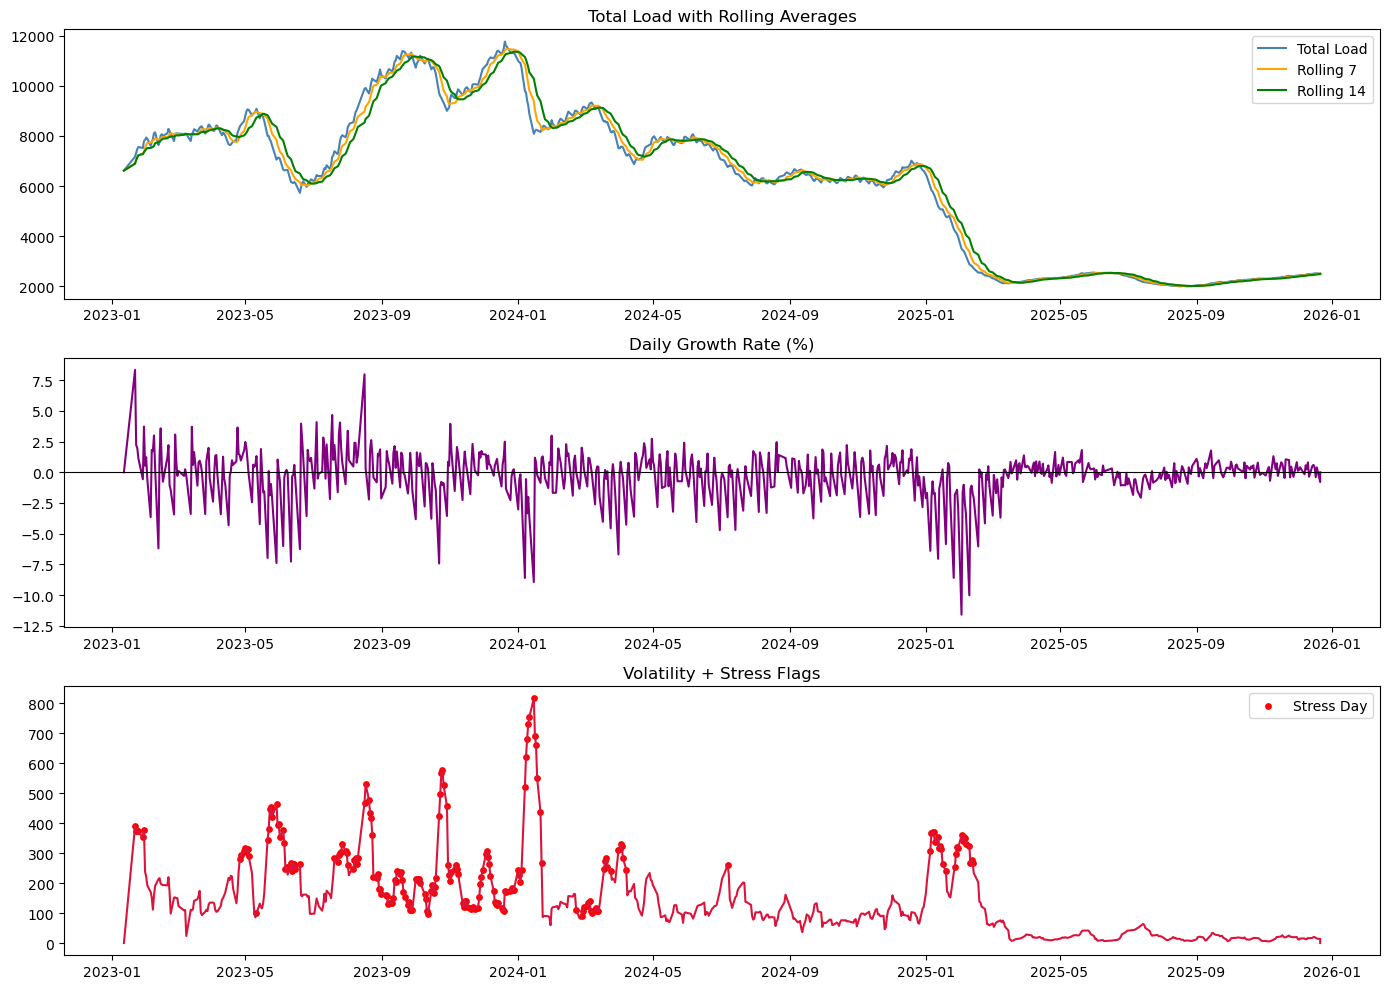

In [27]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10))
ax[0].plot(df["Date"], df["total_load"], label="Total Load", color="steelblue")
ax[0].plot(df["Date"], df["rolling_7"], label="Rolling 7", color="orange")
ax[0].plot(df["Date"], df["rolling_14"], label="Rolling 14", color="green")
ax[0].set_title("Total Load with Rolling Averages"); ax[0].legend()
ax[1].plot(df["Date"], df["growth_rate"], color="purple"); ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("Daily Growth Rate (%)")
ax[2].plot(df["Date"], df["volatility"], color="crimson")
ax[2].scatter(df.loc[df["stress_flag"] == 1, "Date"], df.loc[df["stress_flag"] == 1, "volatility"], color="red", s=15, label="Stress Day")
ax[2].set_title("Volatility + Stress Flags"); ax[2].legend()
plt.tight_layout(); plt.show()

In [28]:
df.to_csv("enhanced.csv", index=False)
df.head()

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake,rolling_7,rolling_14,growth_rate,volatility,stress_flag_load,stress_flag_volatility,stress_flag
0,2023-01-12,33.0,53.0,34.0,6566,436.0,6619.0,-402.0,6619.00,6619.00,0.000000,0.000000,0,0,0
1,2023-01-22,32.0,49.0,39.0,7122,227.0,7171.0,-188.0,6895.00,6895.00,8.339628,390.322943,0,1,1
2,2023-01-23,32.0,50.0,39.0,7280,181.0,7330.0,-142.0,7040.00,7040.00,2.217264,373.163503,0,1,1
3,2023-01-24,47.0,42.0,47.0,7433,175.0,7475.0,-128.0,7148.75,7148.75,1.978172,374.353109,0,1,1
4,2023-01-25,20.0,22.0,41.0,7538,180.0,7560.0,-139.0,7231.00,7231.00,1.137124,372.733819,0,1,1


In [29]:
df["discharge_ratio"] = df["discharges"] / df["transfers"].replace(0, np.nan)
df["discharge_ratio"] = df["discharge_ratio"].fillna(0).clip(0, 5)

In [30]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake,rolling_7,rolling_14,growth_rate,volatility,stress_flag_load,stress_flag_volatility,stress_flag,discharge_ratio
492,2025-01-16,106.0,196.0,131.0,4881,159.0,5077.0,-28.0,5259.714286,5747.571429,0.23692,262.869241,0,1,1,1.213740
867,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.00000,0.000000,0,0,0,1.272727
1050,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.00000,0.000000,0,0,0,1.272727
742,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.00000,0.000000,0,0,0,1.272727
857,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.00000,0.000000,0,0,0,1.272727


In [31]:
df["backlog"] = (df["transfers"] - df["discharges"]).cumsum()
load_norm = (df["total_load"] - df["total_load"].min()) / (df["total_load"].max() - df["total_load"].min() + 1e-9)
vol_norm = (df["volatility"] - df["volatility"].min()) / (df["volatility"].max() - df["volatility"].min() + 1e-9)
disc_norm = 1 - df["discharge_ratio"].clip(0, 1)
df["pressure_index"] = (0.5 * load_norm + 0.3 * vol_norm + 0.2 * disc_norm) * 100

In [32]:
df.sample(10)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake,rolling_7,rolling_14,growth_rate,volatility,stress_flag_load,stress_flag_volatility,stress_flag,discharge_ratio,backlog,pressure_index
776,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0,1.272727,-32383.0,2.561475
1049,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0,1.272727,-33202.0,2.561475
927,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0,1.272727,-32836.0,2.561475
495,2025-01-21,59.0,64.0,117.0,4728,54.0,4792.0,63.0,4953.857143,5362.714286,0.756939,167.773089,0,0,0,0.461538,-30231.0,31.220538
1004,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0,1.272727,-33067.0,2.561475
295,2024-04-03,124.0,230.0,190.0,7346,163.0,7576.0,27.0,7798.285714,8128.000000,0.079260,325.560396,0,1,1,0.857895,-33107.0,43.347444
666,2025-10-02,20.0,51.0,15.0,2164,16.0,2215.0,-1.0,2186.142857,2169.428571,0.865209,16.108265,0,0,0,1.066667,-32239.0,1.682458
340,2024-06-06,179.0,326.0,282.0,7741,238.0,8067.0,44.0,7951.714286,7840.357143,0.385764,81.497882,0,0,0,0.843972,-31455.0,37.182723
783,2025-12-21,6.0,18.0,11.0,2484,14.0,2502.0,-3.0,2502.000000,2502.000000,0.000000,0.000000,0,0,0,1.272727,-32404.0,2.561475
450,2024-11-18,143.0,203.0,163.0,5819,138.0,6022.0,25.0,6161.571429,6238.714286,-0.066379,113.166334,0,0,0,0.846626,-30253.0,27.815627


In [33]:
df["bottleneck"] = np.where(df["cbp_custody"] > df["hhs_care"], "CBP", "HHS")

In [34]:
df["stability_score"] = (100 - df["pressure_index"]).clip(0, 100)

In [35]:
df.sample(5)

,Date,cbp_intake,cbp_custody,transfers,hhs_care,discharges,total_load,net_intake,rolling_7,rolling_14,growth_rate,volatility,stress_flag_load,stress_flag_volatility,stress_flag,discharge_ratio,backlog,pressure_index,bottleneck,stability_score
461,2024-12-03,81.0,230.0,242.0,6192,107.0,6422.0,135.0,6241.000000,6152.428571,0.485057,147.704660,0,0,0,0.442149,-29710.0,39.222110,HHS,60.777890
535,2025-03-19,6.0,22.0,14.0,2119,9.0,2141.0,5.0,2132.714286,2191.500000,-0.093327,7.364652,0,0,0,0.642857,-31821.0,8.125274,HHS,91.874726
115,2023-07-11,115.0,216.0,169.0,6498,143.0,6714.0,26.0,6448.714286,6293.357143,1.958998,164.780373,0,0,0,0.846154,-12037.0,33.264691,HHS,66.735309
184,2023-10-23,86.0,152.0,168.0,9436,327.0,9588.0,-159.0,10361.142857,10693.142857,-1.175015,497.588662,1,1,1,1.946429,-22100.0,57.127180,HHS,42.872820
80,2023-05-18,80.0,122.0,152.0,8474,351.0,8596.0,-199.0,8831.142857,8880.000000,-1.546215,167.232800,0,0,0,2.309211,-9040.0,39.919180,HHS,60.080820


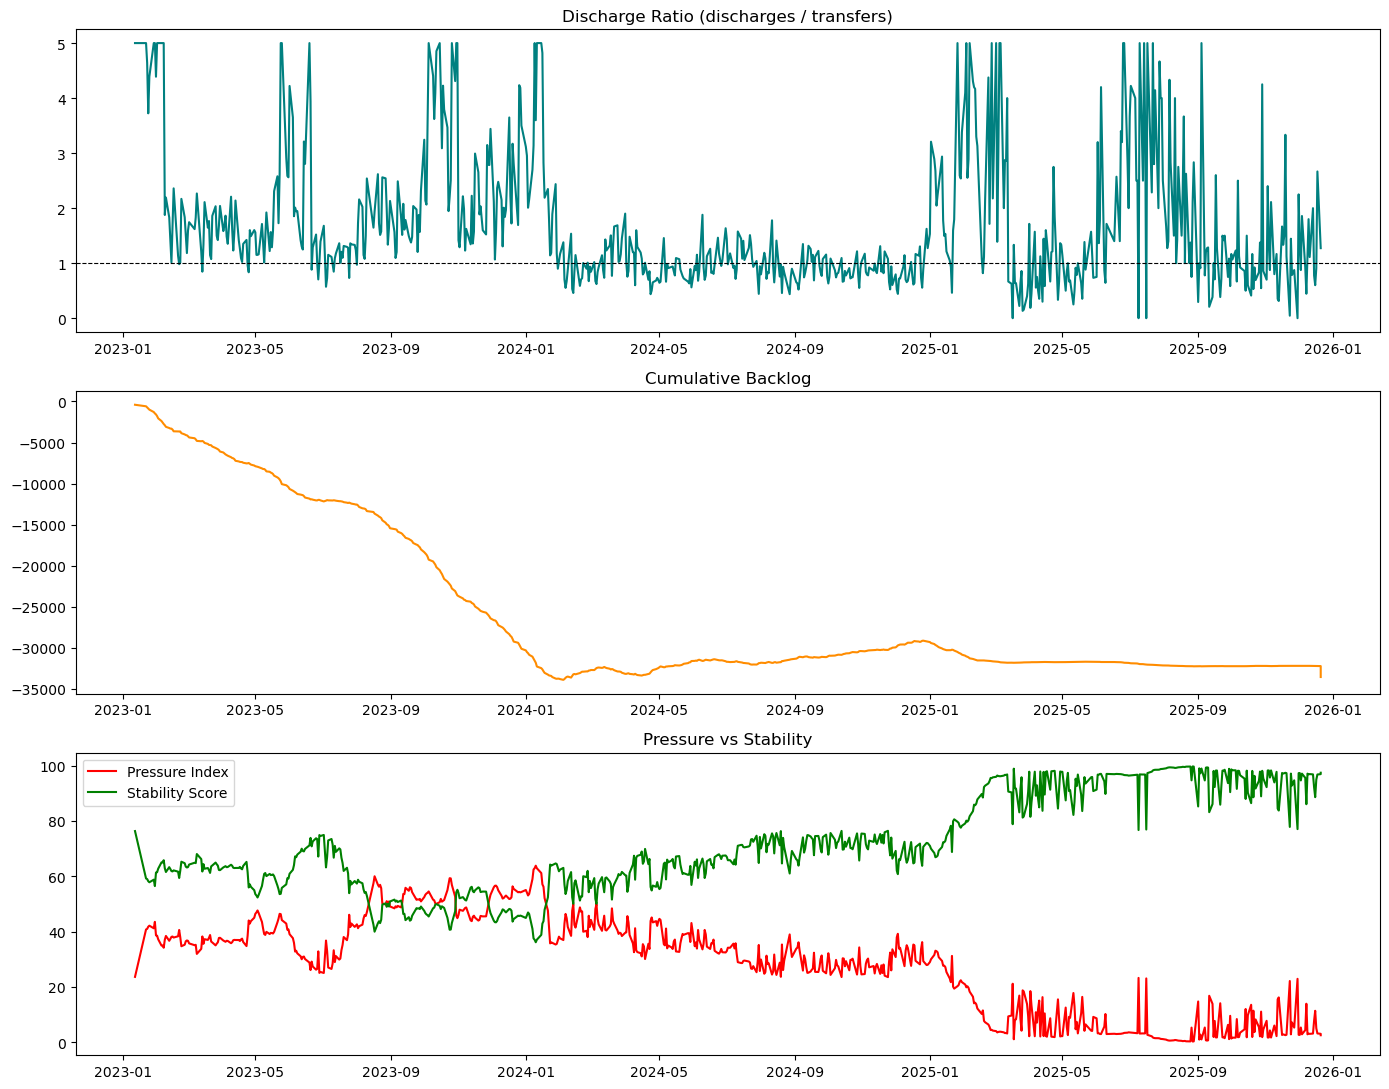

In [36]:
fig, ax = plt.subplots(3, 1, figsize=(14, 11))
ax[0].plot(df["Date"], df["discharge_ratio"], color="teal")
ax[0].axhline(1, color="black", ls="--", lw=0.8)
ax[0].set_title("Discharge Ratio (discharges / transfers)")
ax[1].plot(df["Date"], df["backlog"], color="darkorange"); ax[1].set_title("Cumulative Backlog")
ax[2].plot(df["Date"], df["pressure_index"], color="red", label="Pressure Index")
ax[2].plot(df["Date"], df["stability_score"], color="green", label="Stability Score")
ax[2].set_title("Pressure vs Stability"); ax[2].legend()
plt.tight_layout(); plt.show()


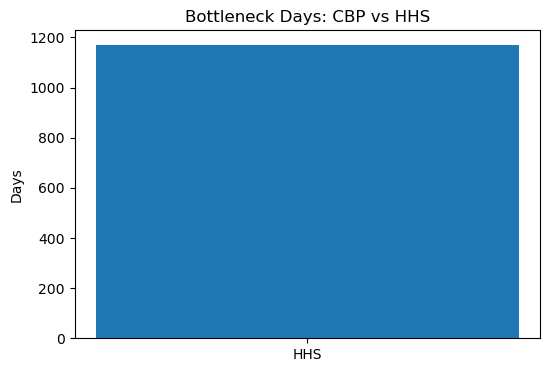

In [37]:
counts = df["bottleneck"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Bottleneck Days: CBP vs HHS"); plt.ylabel("Days"); plt.show()

In [38]:
df.to_csv("day3_kpi.csv", index=False)

In [39]:
!pip install prophet

In [40]:
from prophet import Prophet

In [41]:
prophet_df = df[["Date", "total_load"]].rename(columns={"Date": "ds", "total_load": "y"})

In [42]:
model= Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, changepoint_prior_scale=0.1)

In [43]:
model.fit(prophet_df)

21:55:28 - cmdstanpy - INFO - Chain [1] start processing
21:55:28 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
future = model.make_future_dataframe(periods=30, freq="D")
forecast = model.predict(future)

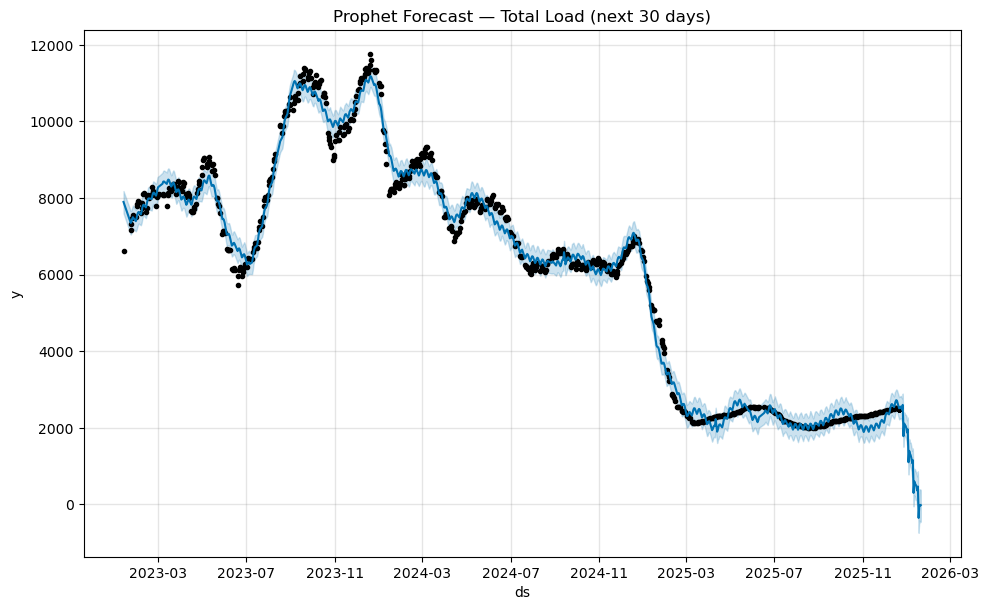

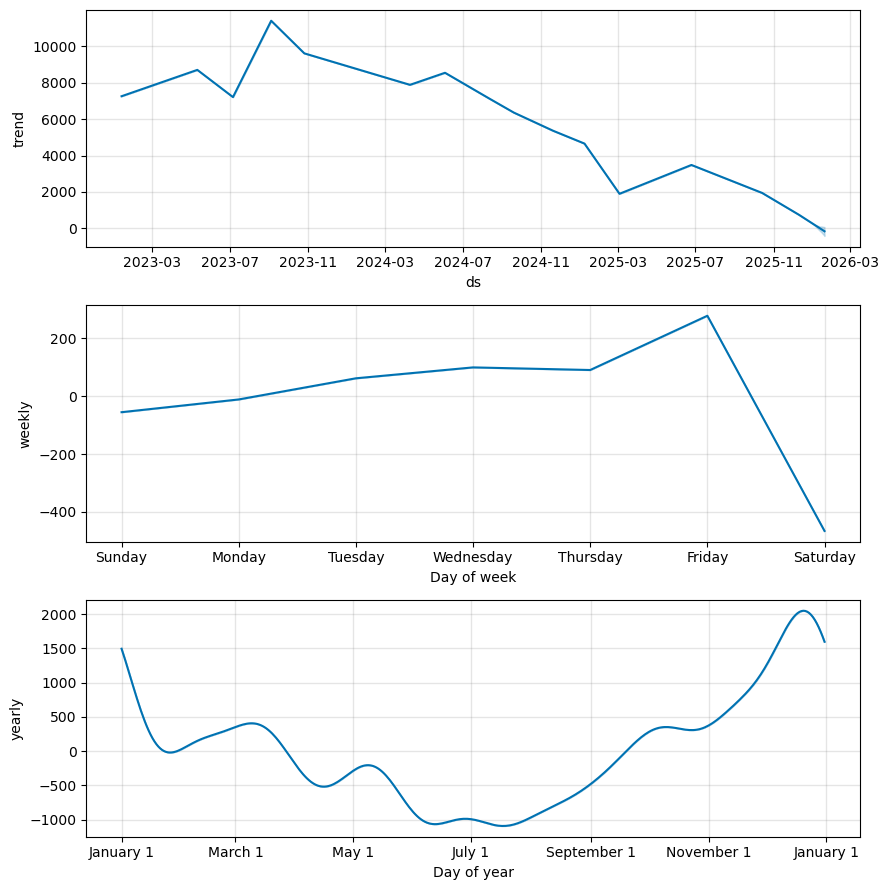

In [45]:
fig1 = model.plot(forecast); plt.title("Prophet Forecast — Total Load (next 30 days)"); plt.show()
fig2 = model.plot_components(forecast); plt.show()

In [46]:
forecast_out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].rename(columns={"ds": "Date"})
forecast_out.to_csv("forecast_output.csv", index=False)
print(forecast_out.tail(30))

          Date         yhat   yhat_lower   yhat_upper
720 2025-12-22  2520.825725  2231.812507  2814.415174
721 2025-12-23  2552.985328  2258.180528  2832.047714
722 2025-12-24  2541.671170  2231.739352  2831.139653
723 2025-12-25  2475.605726  2180.168413  2770.453634
724 2025-12-26  2598.360282  2319.144137  2894.766414
725 2025-12-27  1781.437058  1505.976062  2088.772424
726 2025-12-28  2112.486135  1801.907589  2405.797873
727 2025-12-29  2069.977441  1790.406999  2357.030244
728 2025-12-30  2050.241139  1760.973162  2346.075445
729 2025-12-31  1989.404771  1678.639453  2316.404477
730 2026-01-01  1876.843749  1553.755503  2198.765471
731 2026-01-02  1956.741762  1656.875081  2270.232936
732 2026-01-03  1101.161275   780.271291  1391.838415
733 2026-01-04  1398.249857  1093.960161  1705.477138
734 2026-01-05  1326.902803  1008.255184  1622.703696
735 2026-01-06  1283.795614   954.061073  1613.658434
736 2026-01-07  1205.314854   874.188763  1508.945331
737 2026-01-08  1081.004123 

In [47]:
import joblib

In [48]:
joblib.dump(model,"prophet_part.pkl")

['prophet_part.pkl']

In [49]:
import os
os.listdir()

['prophet_part.pkl',
 'Project1.ipynb',
 'forecast_output.csv',
 'all_models.pkl',
 'day1_cleaned.csv',
 'rf_model.pkl',
 'ml_predictions.csv',
 'my_project1.csv',
 'app.py',
 '.ipynb_checkpoints',
 'enhanced.csv',
 'day3_kpi.csv']

In [50]:
!pip install xgboost

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [52]:
df["lag_1"] = df["total_load"].shift(1)
df["lag_7"] = df["total_load"].shift(7)
df["lag_14"] = df["total_load"].shift(14)

In [53]:
feature_cols = ["lag_1", "lag_7", "lag_14", "net_intake", "rolling_7", "rolling_14"]
target_col = "total_load"

In [54]:
ml_df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

In [55]:
split_idx = len(ml_df) - 90
train = ml_df.iloc[:split_idx]
test = ml_df.iloc[split_idx:]

In [56]:
X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

In [57]:
tscv = TimeSeriesSplit(n_splits=5)

In [58]:
rf_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [8, 12, 20],
    "min_samples_leaf": [1, 2, 4],
}
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)

In [59]:
rf_search.fit(X_train, y_train)


Fitting 5 folds for each of 27 candidates, totalling 135 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [8, 12, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [200, 400, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,600


In [60]:
xgb_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
}
xgb_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror", tree_method="hist"),
    xgb_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)

In [61]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [200, 400, ...], 'subsample': [0.8, 1.0]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [62]:
rf_best = rf_search.best_estimator_
xgb_best = xgb_search.best_estimator_

In [63]:
rf_pred = rf_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

In [64]:
def metrics(y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    return mae, rmse

In [65]:
rf_mae, rf_rmse = metrics(y_test, rf_pred)
xgb_mae, xgb_rmse = metrics(y_test, xgb_pred)

In [66]:
comparison = pd.DataFrame({
    "model": ["RandomForest", "XGBoost"],
    "cv_mae": [-rf_search.best_score_, -xgb_search.best_score_],
    "test_mae": [rf_mae, xgb_mae],
    "test_rmse": [rf_rmse, xgb_rmse],
    "best_params": [rf_search.best_params_, xgb_search.best_params_],
})
print(comparison)

          model      cv_mae  test_mae  test_rmse  \
0  RandomForest  275.196171  0.036373   0.036373   
1       XGBoost  288.038889  0.193848   0.193848   

                                         best_params  
0  {'max_depth': 8, 'min_samples_leaf': 4, 'n_est...  
1  {'learning_rate': 0.1, 'max_depth': 4, 'n_esti...  


In [67]:
winner_name = comparison.loc[comparison["test_mae"].idxmin(), "model"]
winner_model = rf_best if winner_name == "RandomForest" else xgb_best
winner_pred = rf_pred if winner_name == "RandomForest" else xgb_pred
winner_mae = rf_mae if winner_name == "RandomForest" else xgb_mae
print(f"Winner: {winner_name} | Test MAE = {winner_mae:.2f}")

Winner: RandomForest | Test MAE = 0.04


In [68]:
importances = pd.Series(winner_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

lag_1         0.531926
rolling_7     0.418263
rolling_14    0.036493
lag_7         0.011153
lag_14        0.001906
net_intake    0.000259
dtype: float64


In [69]:
rf_search.score(X_test,y_test)

-0.036372667452269525

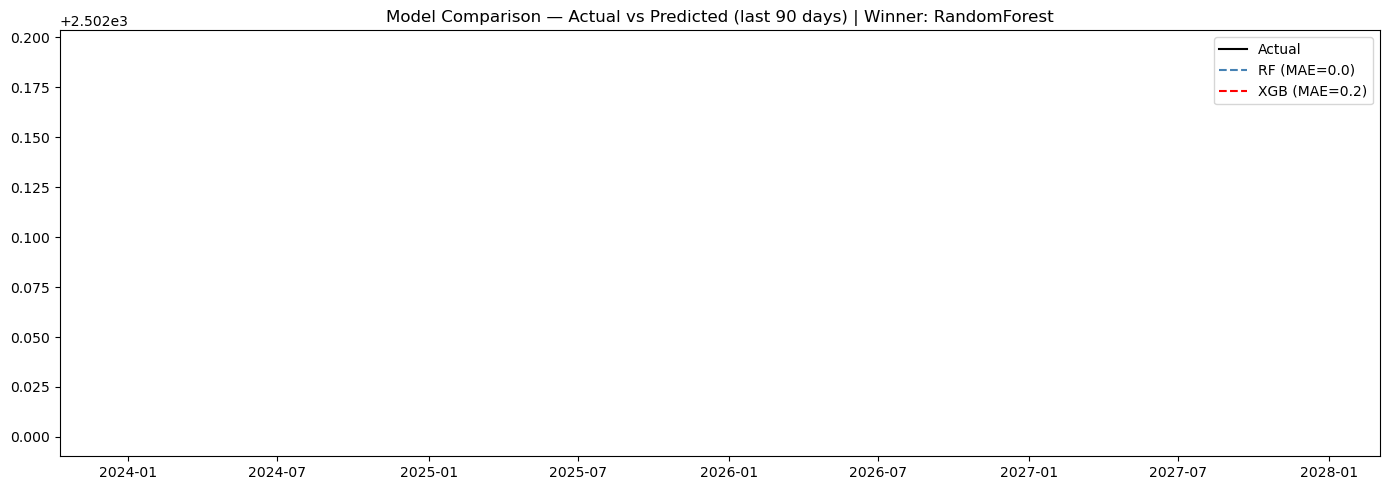

In [70]:
plt.figure(figsize=(14, 5))
plt.plot(test["Date"], y_test.values, label="Actual", color="black")
plt.plot(test["Date"], rf_pred, label=f"RF (MAE={rf_mae:.1f})", color="steelblue", ls="--")
plt.plot(test["Date"], xgb_pred, label=f"XGB (MAE={xgb_mae:.1f})", color="red", ls="--")
plt.title(f"Model Comparison — Actual vs Predicted (last 90 days) | Winner: {winner_name}")
plt.legend(); plt.tight_layout(); plt.show()

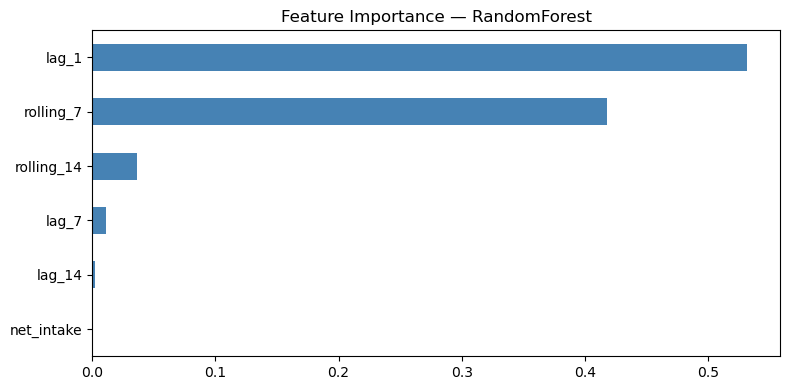

In [71]:
plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="steelblue")
plt.title(f"Feature Importance — {winner_name}"); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

In [72]:
ml_predictions = test[["Date"]].copy()
ml_predictions["actual"] = y_test.values
ml_predictions["predicted"] = winner_pred
ml_predictions["rf_predicted"] = rf_pred
ml_predictions["xgb_predicted"] = xgb_pred
ml_predictions.to_csv("ml_predictions.csv", index=False)

In [73]:
joblib.dump(winner_model, "rf_model.pkl")
joblib.dump({"rf": rf_best, "xgb": xgb_best, "winner": winner_name}, "all_models.pkl")

['all_models.pkl']